# Act 2 - Ai đang làm rò rỉ margin?

**Câu hỏi trung tâm:** Promotion có thật sự kéo về khách hàng tốt, hay chỉ tạo volume rẻ với unit economics kém?

Act này giữ đúng kế hoạch: dùng Promo ROI Scatter và Cohort Quality để kiểm tra cơ chế gây rò rỉ margin. Return behavior là kiểm định phụ; bằng chứng chính nằm ở repeat rate và gross-profit contribution/customer.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "outputs").exists() and (ROOT.parent / "outputs").exists():
    ROOT = ROOT.parent
CHARTS = ROOT / "outputs" / "charts"
TABLES = ROOT / "outputs" / "tables"


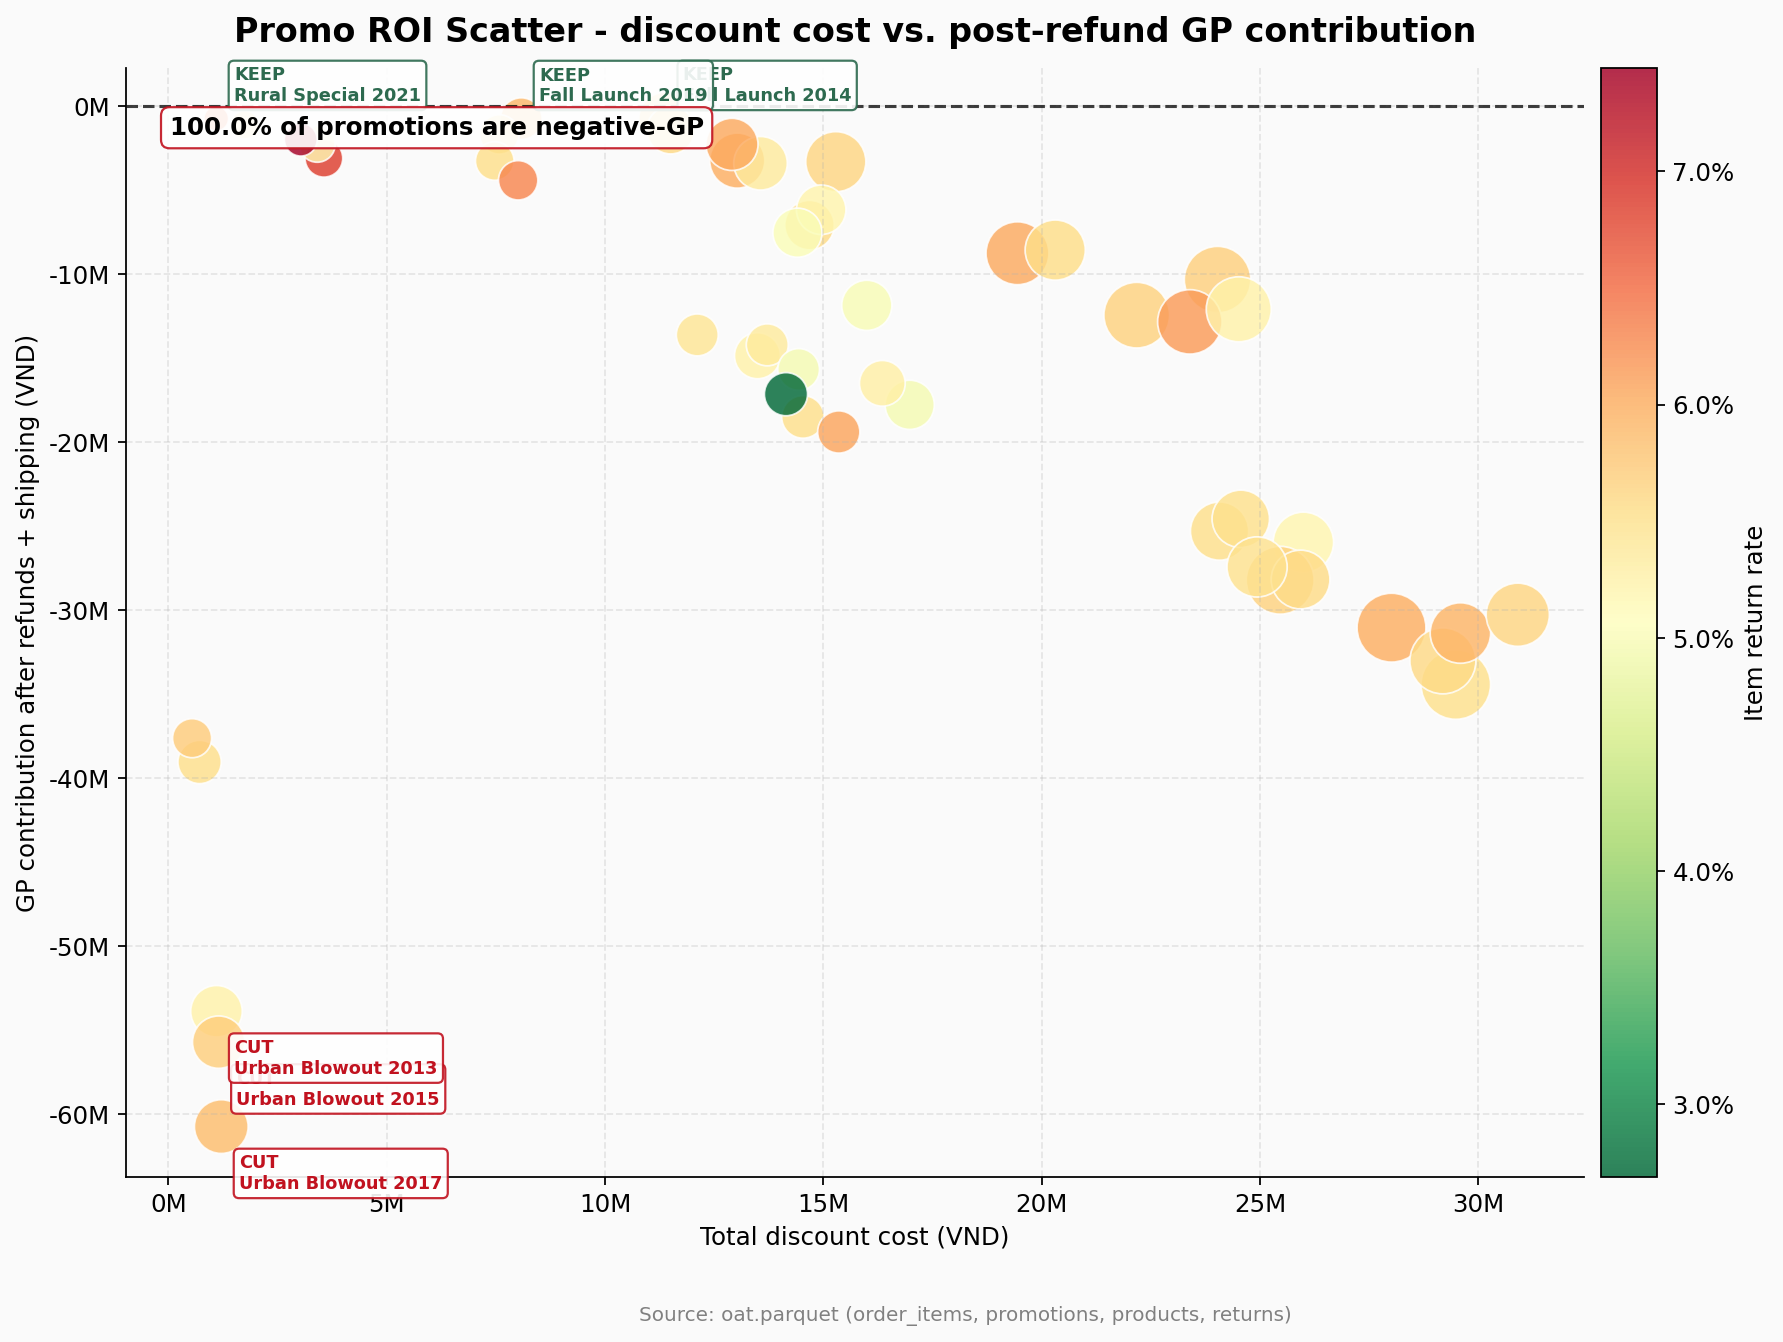

In [2]:
display(Image(str(CHARTS / "chart3_promo_roi_scatter.png"), width=950))


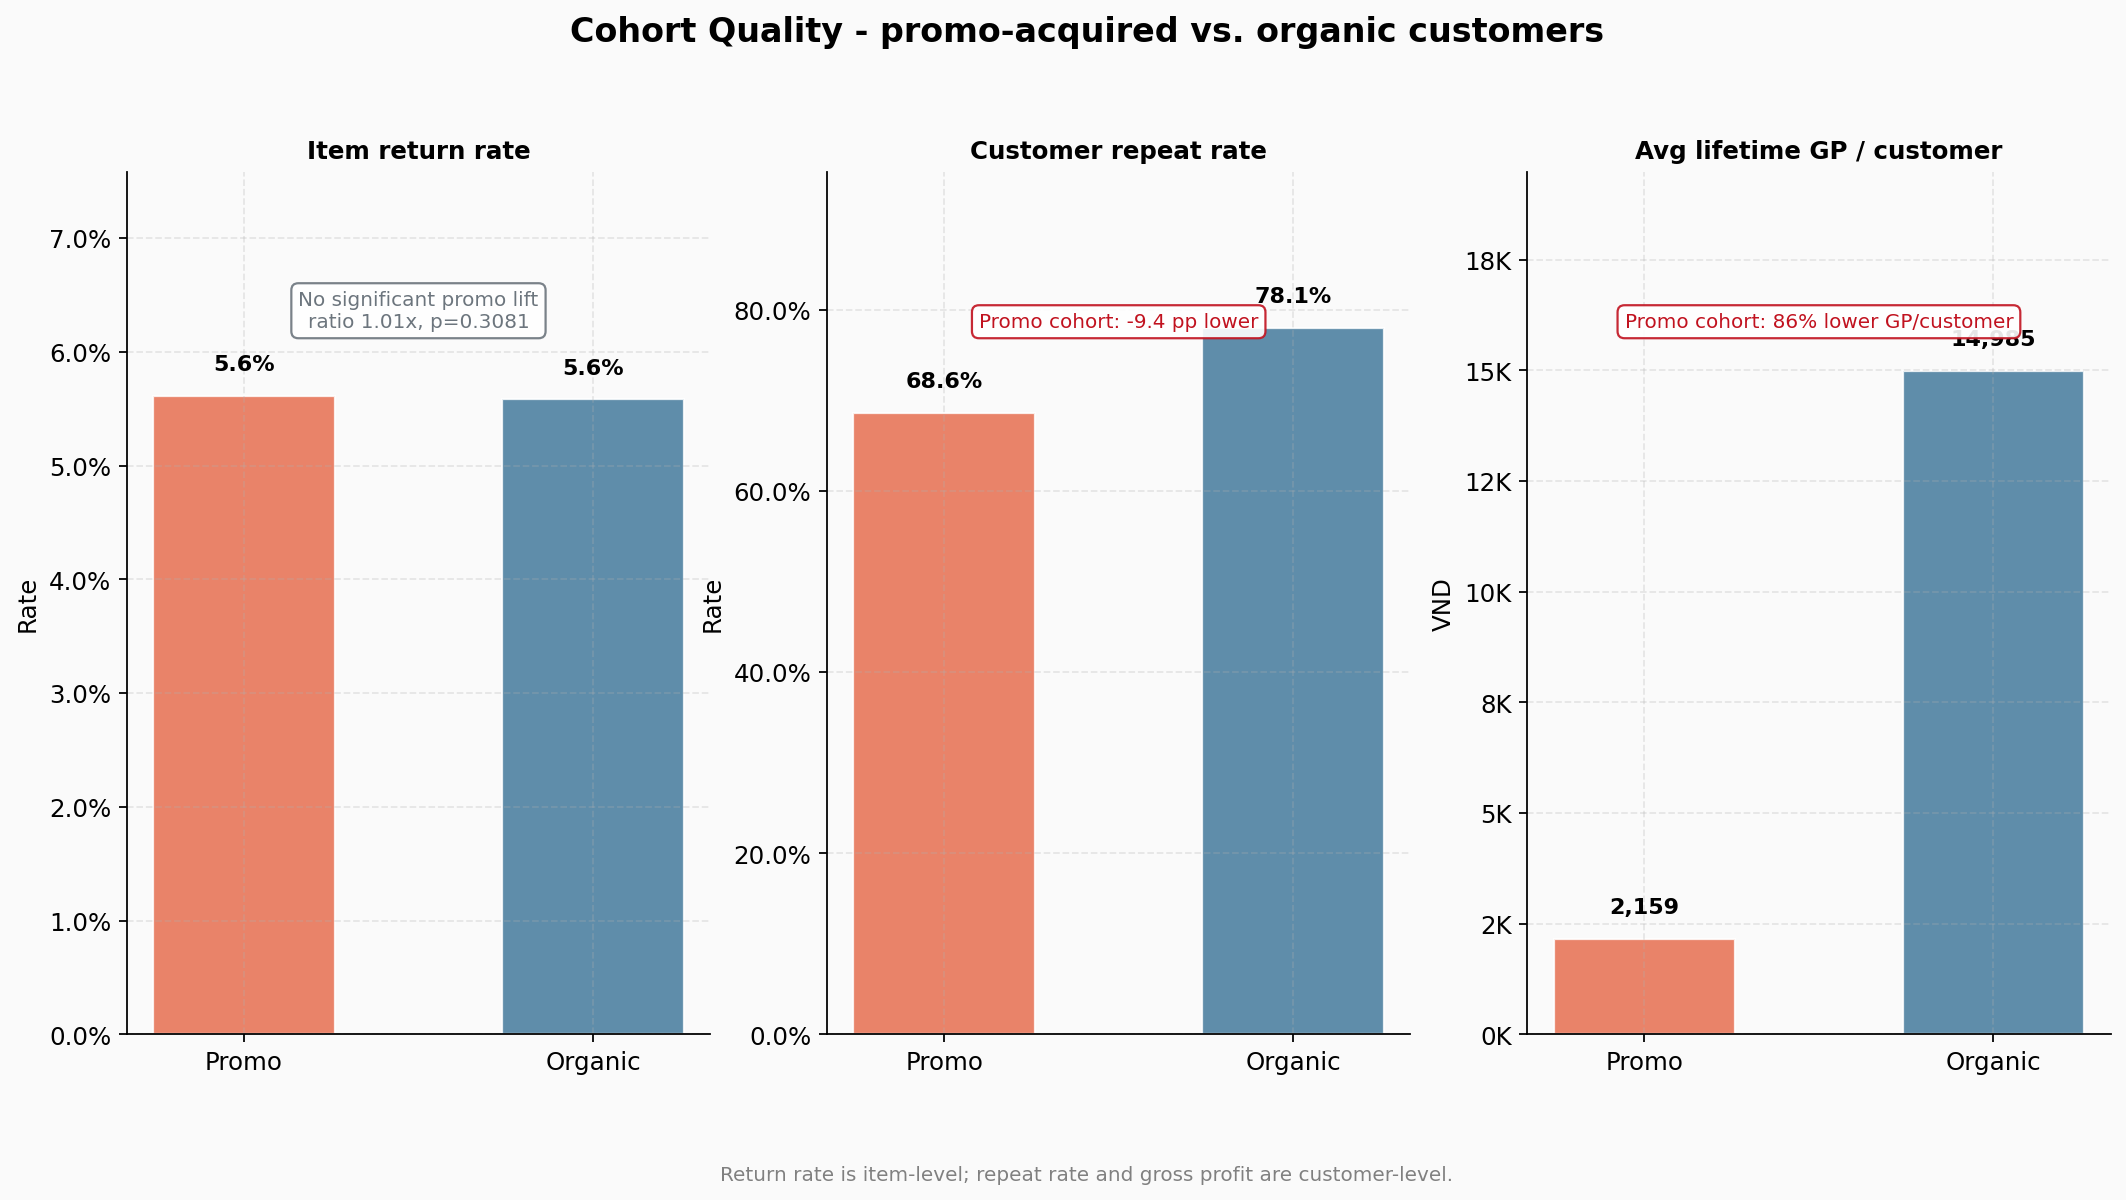

In [3]:
display(Image(str(CHARTS / "chart4_cohort_quality.png"), width=950))


In [4]:
triage = pd.read_csv(TABLES / "promo_triage_table.csv")
cohort = pd.read_csv(TABLES / "cohort_quality_table.csv")
print(f"Tỷ lệ promotion có GP contribution âm: {(triage['total_net_contribution'] < 0).mean() * 100:.1f}%")
display(cohort)


Tỷ lệ promotion có GP contribution âm: 100.0%


,metric,promo,organic,difference
0,item_return_rate,0.056157,0.055817,0.000341
1,customer_repeat_rate,0.686391,0.780608,-0.094217
2,avg_lifetime_gp_per_customer,2158.906127,14985.089993,-12826.183867


## Phân tích

Sau khi tính refund và shipping, **100.0% promotion có GP contribution âm**. Đây là kết quả rất mạnh: toàn bộ promo template lịch sử trong data đều không qua được gross-profit screen.

Cohort analysis cho thấy **item return rate của promo-acquired customers không cao hơn một cách có ý nghĩa thống kê**: promo **5.6%**, organic **5.6%**, Mann-Whitney one-sided **p = 0.3081**. Vì vậy không nên nói promotion làm return tăng.

Thesis vẫn đứng nhờ hai chỉ số khác:

- Customer repeat rate: promo **68.6%** vs organic **78.1%**.
- Average lifetime GP/customer sau refund và shipping: promo **2,159 VND** vs organic **14,985 VND**, thấp hơn **86%**.

**Kết luận Act 2:** Promotion damage chủ yếu đến từ margin compression và cohort economics yếu, không phải từ return behavior.
